In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor
os.makedirs("outputs", exist_ok=True)

In [6]:

df = pd.read_parquet("daily_features_v2.parquet")

target = "pm2_5_corrected"
identifiers = ["station_id", "day"]
cat_targets = ["aqi_category", "is_health_risk"]

feature_cols = [
    c for c in df.columns
    if c not in [target] + identifiers + cat_targets
]

X_num = df[feature_cols].select_dtypes(include=[np.number])
X_num = X_num.fillna(X_num.median())
y = df[target]

In [7]:

lgb_model = LGBMRegressor(random_state=42, n_jobs=-1)
lgb_model.fit(X_num, y)

importances = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=X_num.columns
).sort_values(ascending=False).head(25)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15604
[LightGBM] [Info] Number of data points in the train set: 5480, number of used features: 97
[LightGBM] [Info] Start training from score 46.082451


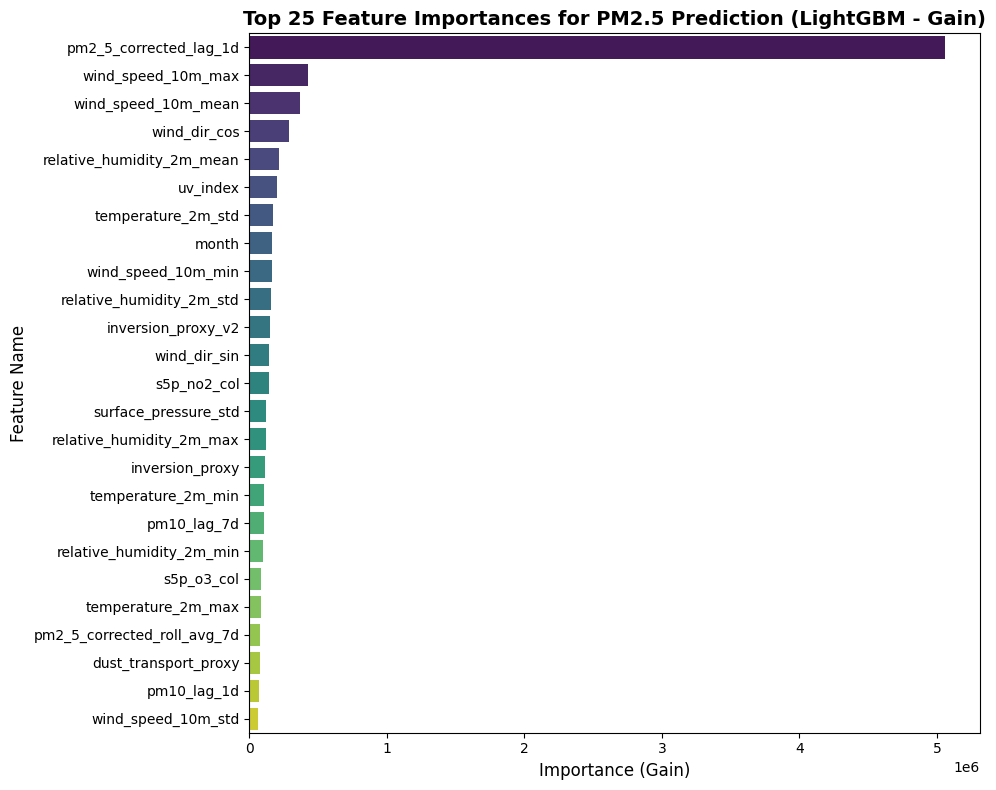

In [8]:

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", hue=importances.index, legend=False)

plt.title("Top 25 Feature Importances for PM2.5 Prediction (LightGBM - Gain)", fontsize=14, fontweight="bold")
plt.xlabel("Importance (Gain)", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.tight_layout()

plt.savefig("outputs/feature_importance_top25_lgbm.png", dpi=300)
plt.show()